# TUTORIAL: Next Sentence Prediction with BERT

- BOOK: [Dive Into DL](https://d2l.ai/chapter_natural-language-processing-pretraining/bert.html)
- NOTEBOOK: [Finetune BERT with IMDB](https://github.com/ufdatastudio/predictions/blob/development/notebook_experiments/tutorial-text_classification_hf-base.ipynb)
- NOTEBOOK: [Finetune BERT with TOLSA-M](https://github.com/ufdatastudio/predictions/blob/development/notebook_experiments/tutorial-text_classification_hf-tolsa_m.ipynb)

---

## Sections:

1. PART 1: 15.8 Bidirectional Encoder Representations from  Transformers (BERT)
2. PART 2: 15.9 The Dataset for Pretraining BERT
3. PART 3: 15.10 Pretraining BERT

In [1]:
import os
import sys
import torch
import random
import zipfile

import urllib.request
import matplotlib_inline.backend_inline as _backend


from torch import nn
from d2l import torch as d2l

# Get the current working directory of the notebook
notebook_dir = os.getcwd()
# Add the parent directory to the system path
sys.path.append(os.path.join(notebook_dir, '../'))

# import log_files
from data_processing import DataProcessing
from metrics import EvaluationMetric

# PART 1: 15.8 Bidirectional Encoder Representations from  Transformers (BERT)

## Input Representation

BERT's text input type is both single and multiple

1. Single Text Input $ \rightarrow $ Tasks with Examples
2. Multiple Text Input $ \rightarrow $ Tasks with Examples
3. CODE: Get Tokens and Segments

### Single Text Input Tasks $ \rightarrow $ Tasks with Examples

| # | Task | Input Example | Output Example |
|---|------|---------------|----------------|
| 1 | Sentiment Analysis | "I absolutely loved this movie." | Positive |
| 2 | Topic Classification | "The Federal Reserve announced a change in interest rates." | Finance |
| 3 | Text Tagging (Named Entity Recognition) | "Barack Obama was born in Hawaii." | Barack Obama → PERSON, Hawaii → LOCATION |
| 4 | Language Identification | "Bonjour tout le monde." | French |
| 5 | Spam Detection | "Congratulations! You have won a free iPhone." | Spam |
| 6 | Emotion Classification | "I am so excited for graduation!" | Joy |
| 7 | Toxicity Detection | "You are terrible at everything." | Toxic |

---

Single: Concatenation of the special classification token `<cls>`, tokens of a text sequence, and the special separation token `<sep>`.

<div align="center"><b>Task: 1 (SA)</b></div>

BERT Input Sequence 1:
    ```
    [CLS] I absolutely loved this movie . [SEP]
    ```

Segment IDs:
    ```
    0 0 0 0 0 0 0 0
    ```

BERT Input Sequence 2:
    ```
    [CLS] The film was a complete waste of time . [SEP]
    ```
    
Segment IDs:
    ```
    0 0 0 0 0 0 0 0 0 0
    ```

### Multiple Text Input Tasks $ \rightarrow $ Tasks with Examples

| # | Task | Input Example 1 | Input Example 2 | Output Example |
|---|------|-----------------|-----------------|----------------|
| 1 | Natural Language Inference (NLI) | Premise: "A man is playing guitar." | Hypothesis: "A person is making music." | Entailment |
| 2 | Semantic Textual Similarity | Sentence 1: "The cat sat on the mat." | Sentence 2: "A cat is sitting on a rug." | Similarity = High |
| 3 | Duplicate Question Detection | Question 1: "How do I learn Python?" | Question 2: "What's the best way to study Python?" | Duplicate |
| 4 | Paraphrase Identification | Sentence 1: "The meeting starts at 9." | Sentence 2: "The meeting begins at 9." | Paraphrase |
| 5 | Information Retrieval / Document Ranking | Query: "Symptoms of diabetes" | Document: "Common symptoms include thirst and fatigue." | Relevant |
| 6 | Question Answering | Context: "Paris is the capital of France." | Question: "What is the capital of France?" | Paris |
| 7 | Dialogue Response Selection | User Message: "What's the weather today?" | Candidate Response: "It will be sunny and 75°F." | Appropriate Response |

Multiple: Concatenation of `<cls>`, tokens of the first text sequence, `<sep>`, tokens of the second text sequence, and `<sep>`.

<div align="center"><b>Task: 1 (NLI) — Pair 1</b></div>

BERT Input Sequence Pair 1:
    ```
    [CLS] A man is playing guitar . [SEP] A person is making music . [SEP]
    ```

Segment IDs:
    ```
    0 0 0 0 0 0 0 0 1 1 1 1 1 1 1
    ```

BERT Input Sequence Pair 2:
    ```
    [CLS] A woman is running outside . [SEP] A person is exercising . [SEP]
    ```

Segment IDs:
    ```
    0 0 0 0 0 0 0 0 1 1 1 1 1 1
    ```

### CODE: Get Tokens and Segments

In [2]:
# @save
def get_tokens_and_segments(tokens_a, tokens_b=None):
    """Get tokens of the BERT input sequence and their segment IDs."""
    tokens = ['<cls>'] + tokens_a + ['<sep>']
    # 0 and 1 are marking segment A and B, respectively
    segments = [0] * (len(tokens_a) + 2)
    if tokens_b is not None:
        tokens += tokens_b + ['<sep>']
        segments += [1] * (len(tokens_b) + 1)
    return tokens, segments

#### Image of BERT across input + token embeddings + segment embeddings + positional embeddings

![alt text](<Screenshot 2026-09-19 at 13.14.50.png>)

## CODE: Transformer Encoder + BERT Encoder

> Transformer Encoder Architecture: Multihead Attention $ \rightarrow $ Feed Forward Network $ \rightarrow $ Layer Normalization (2x) $ \rightarrow $ Dropout

- **Two components:**
    1. Encoder [convert input sequence into a sequence of vectors] [2 | Lecture 11]
    2. Decoder: [convert encoding into a sequence in the output space] [2 | Lecture 11]

- **Why:**
    1. Attention allows the model to attend to different parts of *another* sequence [2 | Lecture 11]
    2. Self-attention allows the model to attend to different parts of the *same* sequence [2 | Lecture 11]
    3. Solves problems of Single-head Self-Attention (SHSA) (RNNs, LSTMs, BLSTMs) [2 | Lecture 8]
        1. A single encoding vector needs to capture all the information about source sentence [2 | Lecture 11]
        2. Longer sequences can lead to vanishing gradients [2 | Lecture 11]

> BERT Encoder Architecture: Token (Word) Embeddings $ \rightarrow $ Segment Embeddings $ \rightarrow $ Transformer Encoder $ \rightarrow $ Positional Embeddings

- **Why:**
    1. Have learnable parameter called positional embedding (unlike the transformer model, so think static learning), so think dynamic learning [1]
    2. Fittted for any task (unlike ELMo, where new model for new tasks), so generalizable/customizable [1]
    3. Pretrained on the concatenation of BookCorpus (Zhu et al., 2015) and English Wikipedia. [1] 
    These two text corpora are huge: they have 800 million words and 2.5 billion words, respectively. [1]

> CODE: Transformer Block

- Becuase I'm getting `AttributeError: module 'd2l.torch' has no attribute 'TransformerEncoderBlock'`, so UF's claude-sonnect-4.6 generated the below.

In [3]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, num_hiddens, ffn_num_hiddens, num_heads, dropout, use_bias=False):
        super().__init__()
        self.attention = nn.MultiheadAttention(num_hiddens, num_heads, dropout=dropout, batch_first=True)
        self.ffn = nn.Sequential(
            nn.Linear(num_hiddens, ffn_num_hiddens),
            nn.ReLU(),
            nn.Linear(ffn_num_hiddens, num_hiddens)
        )
        self.norm1 = nn.LayerNorm(num_hiddens)
        self.norm2 = nn.LayerNorm(num_hiddens)
        self.dropout = nn.Dropout(dropout)

    def forward(self, X, valid_lens=None):
        attn_out, _ = self.attention(X, X, X)
        X = self.norm1(X + self.dropout(attn_out))
        ffn_out = self.ffn(X)
        return self.norm2(X + self.dropout(ffn_out))

# Monkey-patch it onto d2l
d2l.TransformerEncoderBlock = TransformerEncoderBlock

In [4]:
#@save
class BERTEncoder(nn.Module):
    """BERT encoder.
    
    Defines its architectual components in `__init__()`:
        embedding layers + stack of Tranform encoder blocks + learnable embedding while using instance attributes
    Defines the foward method (shows how data flows)

    """
    def __init__(self, vocab_size, num_hiddens, ffn_num_hiddens, num_heads,
                 num_blks, dropout, max_len=1000, **kwargs):
        super(BERTEncoder, self).__init__(**kwargs)
        
        """ Embedding layers """
        self.token_embedding = nn.Embedding(vocab_size, num_hiddens) # word level (token) embedding
        self.segment_embedding = nn.Embedding(2, num_hiddens) # distinguishing text pairs

        """Transformer encoder blocks """
        self.blks = nn.Sequential()
        for i in range(num_blks):
            self.blks.add_module(f"{i}", d2l.TransformerEncoderBlock(
                num_hiddens, ffn_num_hiddens, num_heads, dropout, True))

        """ Learnable embedding layer """
        # In BERT, positional embeddings are learnable, thus we create a
        # parameter of positional embeddings that are long enough
        self.pos_embedding = nn.Parameter(torch.randn(1, max_len,
                                                      num_hiddens))

    def forward(self, tokens, segments, valid_lens):
        # Shape of `X` remains unchanged in the following code snippet:
        # (batch size, max sequence length, `num_hiddens`)
        X = self.token_embedding(tokens) + self.segment_embedding(segments)
        X = X + self.pos_embedding[:, :X.shape[1], :]
        for blk in self.blks:
            X = blk(X, valid_lens)
        return X

> Create instance and initialize its parameters

In [5]:
vocab_size, num_hiddens, ffn_num_hiddens, num_heads = 10000, 768, 1024, 4
ffn_num_input, num_blks, dropout = 768, 2, 0.2
encoder = BERTEncoder(
    vocab_size, 
    num_hiddens, 
    ffn_num_hiddens, 
    num_heads,
    num_blks, dropout
    )

| Code | Meaning |
|------|---------|
| `torch.randint(0, vocab_size, (2, 8))` | Creates **2 sequences, each of length 8** — every value is a random integer index into the vocabulary (0 to 9999). This is where the "2 input sequences of length 8" comes from. |
| `(2, 8)` | The shape of `tokens`: **2** = number of BERT input sequences, **8** = number of tokens per sequence. |
| `[0, 0, 0, 0, 1, 1, 1, 1]` | Segment IDs for the **1st** BERT input sequence — first 4 tokens belong to segment A (`0`s), last 4 tokens belong to segment B (`1`s). This is a **multiple input** sequence (two sentences packed into one). |
| `[0, 0, 0, 1, 1, 1, 1, 1]` | Segment IDs for the **2nd** BERT input sequence — first 3 tokens belong to segment A (`0`s), last 5 tokens belong to segment B (`1`s). Also a **multiple input** sequence, just with a different split point. |
| `encoder(tokens, segments, None)` | Runs the forward pass — sums token, segment, and positional embeddings, then passes through the Transformer encoder blocks. `None` means no masking of valid lengths. |
| `encoded_X.shape` → `torch.Size([2, 8, 768])` | Output shape: **2** sequences × **8** tokens × **768** hidden units (`num_hiddens`). Every token in every sequence is now represented as a 768-dimensional vector [1]. |

--- 

> NOTE: `forward()` is never called directly. Instead, calling `encoder(tokens, segments, valid_lens)`
triggers `nn.Module.__call__()`, which internally invokes `forward()` — along with
any registered PyTorch hooks. Always call the model instance like a function, not `encoder.forward(...)`.

In [6]:
tokens = torch.randint(0, vocab_size, (2, 8))
segments = torch.tensor(
    [[0, 0, 0, 0, 1, 1, 1, 1],   # input sequence 1
    [0, 0, 0, 1, 1, 1, 1, 1]]    # input sequence 2
    )  
encoded_X = encoder(tokens, segments, None)
encoded_X.shape

torch.Size([2, 8, 768])

## CODE: MaskLM Task

> MaskLM $ \rightarrow $ MLP Architecture: Linear $ \rightarrow $ ReLU $ \rightarrow $ Layer Normalization $ \rightarrow $ Linear

- **Why:**
    1. For the BERT model to predict the masked token. [1]
    2. Use BERT model as it can predict the masked token bidirectionally. [1]
    This is advantageous because language models predicts a token using the context on its left. [1]
    3. Use MLP because...

In [7]:
#@save
class MaskLM(nn.Module):
    """The masked language model task of BERT."""
    def __init__(self, vocab_size, num_hiddens, **kwargs):
        super(MaskLM, self).__init__(**kwargs)
        self.mlp = nn.Sequential(nn.LazyLinear(num_hiddens),
                                 nn.ReLU(),
                                 nn.LayerNorm(num_hiddens),
                                 nn.LazyLinear(vocab_size))

    def forward(self, X, pred_positions):
        num_pred_positions = pred_positions.shape[1]
        pred_positions = pred_positions.reshape(-1)
        batch_size = X.shape[0]
        batch_idx = torch.arange(0, batch_size)
        # Suppose that `batch_size` = 2, `num_pred_positions` = 3, then
        # `batch_idx` is `torch.tensor([0, 0, 0, 1, 1, 1])`
        batch_idx = torch.repeat_interleave(batch_idx, num_pred_positions)
        masked_X = X[batch_idx, pred_positions]
        masked_X = masked_X.reshape((batch_size, num_pred_positions, -1))
        mlm_Y_hat = self.mlp(masked_X)
        return mlm_Y_hat

In [8]:
mlm = MaskLM(vocab_size, num_hiddens)
mlm_positions = torch.tensor([[1, 5, 2], [6, 1, 5]])
mlm_Y_hat = mlm(encoded_X, mlm_positions)
mlm_Y_hat.shape

torch.Size([2, 3, 10000])

In [9]:
mlm_Y = torch.tensor([[7, 8, 9], [10, 20, 30]])
loss = nn.CrossEntropyLoss(reduction='none')
mlm_l = loss(mlm_Y_hat.reshape((-1, vocab_size)), mlm_Y.reshape(-1))
mlm_l.shape

torch.Size([6])

## CODE: NextSentencePred Task

> Architecture: Linear (output)

In [10]:
#@save
class NextSentencePred(nn.Module):
    """The next sentence prediction task of BERT."""
    def __init__(self, **kwargs):
        super(NextSentencePred, self).__init__(**kwargs)
        self.output = nn.LazyLinear(2)

    def forward(self, X):
        # `X` shape: (batch size, `num_hiddens`)
        return self.output(X)

In [11]:
# PyTorch by default will not flatten the tensor as seen in mxnet where, if
# flatten=True, all but the first axis of input data are collapsed together
encoded_X = torch.flatten(encoded_X, start_dim=1)
# input_shape for NSP: (batch size, `num_hiddens`)
nsp = NextSentencePred()
nsp_Y_hat = nsp(encoded_X)
nsp_Y_hat.shape

torch.Size([2, 2])

In [12]:
nsp_y = torch.tensor([0, 1])
nsp_l = loss(nsp_Y_hat, nsp_y)
nsp_l.shape

torch.Size([2])

## CODE: BERT Model

> Architecture: BERTEncoder $ \rightarrow $ Hidden Layer $ \rightarrow $ MaskLM $ \rightarrow $ NextSentencePred

In [13]:
#@save
class BERTModel(nn.Module):
    """The BERT model."""
    def __init__(self, vocab_size, num_hiddens, ffn_num_hiddens,
                 num_heads, num_blks, dropout, max_len=1000):
        super(BERTModel, self).__init__()
        self.encoder = BERTEncoder(vocab_size, num_hiddens, ffn_num_hiddens,
                                   num_heads, num_blks, dropout,
                                   max_len=max_len)
        self.hidden = nn.Sequential(nn.LazyLinear(num_hiddens),
                                    nn.Tanh())
        self.mlm = MaskLM(vocab_size, num_hiddens)
        self.nsp = NextSentencePred()

    def forward(self, tokens, segments, valid_lens=None, pred_positions=None):
        encoded_X = self.encoder(tokens, segments, valid_lens)
        if pred_positions is not None:
            mlm_Y_hat = self.mlm(encoded_X, pred_positions)
        else:
            mlm_Y_hat = None
        # The hidden layer of the MLP classifier for next sentence prediction.
        # 0 is the index of the '<cls>' token
        nsp_Y_hat = self.nsp(self.hidden(encoded_X[:, 0, :]))
        return encoded_X, mlm_Y_hat, nsp_Y_hat

# PART 2: 15.9 The Dataset for Pretraining BERT

## Defining Helper Functions for Pretraining Tasks

1. Generating the Next Sentence Prediction Task
2. Generating the Masked Language Modeling Task

In [14]:
#@save
def _get_next_sentence(sentence, next_sentence, paragraphs):
    if random.random() < 0.5:
        is_next = True
    else:
        # `paragraphs` is a list of lists of lists
        next_sentence = random.choice(random.choice(paragraphs))
        is_next = False
    return sentence, next_sentence, is_next

In [15]:
#@save
def _get_nsp_data_from_paragraph(paragraph, paragraphs, vocab, max_len):
    nsp_data_from_paragraph = []
    for i in range(len(paragraph) - 1):
        tokens_a, tokens_b, is_next = _get_next_sentence(
            paragraph[i], paragraph[i + 1], paragraphs)
        # Consider 1 '<cls>' token and 2 '<sep>' tokens
        if len(tokens_a) + len(tokens_b) + 3 > max_len:
            continue
        tokens, segments = d2l.get_tokens_and_segments(tokens_a, tokens_b)
        nsp_data_from_paragraph.append((tokens, segments, is_next))
    return nsp_data_from_paragraph

### Generating the Masked Language Modeling Task

In [16]:
#@save
def _replace_mlm_tokens(tokens, candidate_pred_positions, num_mlm_preds,
                        vocab):
    # For the input of a masked language model, make a new copy of tokens and
    # replace some of them by '<mask>' or random tokens
    mlm_input_tokens = [token for token in tokens]
    pred_positions_and_labels = []
    # Shuffle for getting 15% random tokens for prediction in the masked
    # language modeling task
    random.shuffle(candidate_pred_positions)
    for mlm_pred_position in candidate_pred_positions:
        if len(pred_positions_and_labels) >= num_mlm_preds:
            break
        masked_token = None
        # 80% of the time: replace the word with the '<mask>' token
        if random.random() < 0.8:
            masked_token = '<mask>'
        else:
            # 10% of the time: keep the word unchanged
            if random.random() < 0.5:
                masked_token = tokens[mlm_pred_position]
            # 10% of the time: replace the word with a random word
            else:
                masked_token = random.choice(vocab.idx_to_token)
        mlm_input_tokens[mlm_pred_position] = masked_token
        pred_positions_and_labels.append(
            (mlm_pred_position, tokens[mlm_pred_position]))
    return mlm_input_tokens, pred_positions_and_labels

In [17]:
#@save
def _get_mlm_data_from_tokens(tokens, vocab):
    candidate_pred_positions = []
    # `tokens` is a list of strings
    for i, token in enumerate(tokens):
        # Special tokens are not predicted in the masked language modeling
        # task
        if token in ['<cls>', '<sep>']:
            continue
        candidate_pred_positions.append(i)
    # 15% of random tokens are predicted in the masked language modeling task
    num_mlm_preds = max(1, round(len(tokens) * 0.15))
    mlm_input_tokens, pred_positions_and_labels = _replace_mlm_tokens(
        tokens, candidate_pred_positions, num_mlm_preds, vocab)
    pred_positions_and_labels = sorted(pred_positions_and_labels,
                                       key=lambda x: x[0])
    pred_positions = [v[0] for v in pred_positions_and_labels]
    mlm_pred_labels = [v[1] for v in pred_positions_and_labels]
    return vocab[mlm_input_tokens], pred_positions, vocab[mlm_pred_labels]

## Transforming Text into the Pretraining Dataset

In [18]:
#@save
def _pad_bert_inputs(examples, max_len, vocab):
    max_num_mlm_preds = round(max_len * 0.15)
    all_token_ids, all_segments, valid_lens,  = [], [], []
    all_pred_positions, all_mlm_weights, all_mlm_labels = [], [], []
    nsp_labels = []
    for (token_ids, pred_positions, mlm_pred_label_ids, segments,
         is_next) in examples:
        all_token_ids.append(torch.tensor(token_ids + [vocab['<pad>']] * (
            max_len - len(token_ids)), dtype=torch.long))
        all_segments.append(torch.tensor(segments + [0] * (
            max_len - len(segments)), dtype=torch.long))
        # `valid_lens` excludes count of '<pad>' tokens
        valid_lens.append(torch.tensor(len(token_ids), dtype=torch.float32))
        all_pred_positions.append(torch.tensor(pred_positions + [0] * (
            max_num_mlm_preds - len(pred_positions)), dtype=torch.long))
        # Predictions of padded tokens will be filtered out in the loss via
        # multiplication of 0 weights
        all_mlm_weights.append(
            torch.tensor([1.0] * len(mlm_pred_label_ids) + [0.0] * (
                max_num_mlm_preds - len(pred_positions)),
                dtype=torch.float32))
        all_mlm_labels.append(torch.tensor(mlm_pred_label_ids + [0] * (
            max_num_mlm_preds - len(mlm_pred_label_ids)), dtype=torch.long))
        nsp_labels.append(torch.tensor(is_next, dtype=torch.long))
    return (all_token_ids, all_segments, valid_lens, all_pred_positions,
            all_mlm_weights, all_mlm_labels, nsp_labels)

In [19]:
#@save
class _WikiTextDataset(torch.utils.data.Dataset):
    def __init__(self, paragraphs, max_len):
        # Input `paragraphs[i]` is a list of sentence strings representing a
        # paragraph; while output `paragraphs[i]` is a list of sentences
        # representing a paragraph, where each sentence is a list of tokens
        paragraphs = [d2l.tokenize(
            paragraph, token='word') for paragraph in paragraphs]
        sentences = [sentence for paragraph in paragraphs
                     for sentence in paragraph]
        self.vocab = d2l.Vocab(sentences, min_freq=5, reserved_tokens=[
            '<pad>', '<mask>', '<cls>', '<sep>'])
        # Get data for the next sentence prediction task
        examples = []
        for paragraph in paragraphs:
            examples.extend(_get_nsp_data_from_paragraph(
                paragraph, paragraphs, self.vocab, max_len))
        # Get data for the masked language model task
        examples = [(_get_mlm_data_from_tokens(tokens, self.vocab)
                      + (segments, is_next))
                     for tokens, segments, is_next in examples]
        # Pad inputs
        (self.all_token_ids, self.all_segments, self.valid_lens,
         self.all_pred_positions, self.all_mlm_weights,
         self.all_mlm_labels, self.nsp_labels) = _pad_bert_inputs(
            examples, max_len, self.vocab)

    def __getitem__(self, idx):
        return (self.all_token_ids[idx], self.all_segments[idx],
                self.valid_lens[idx], self.all_pred_positions[idx],
                self.all_mlm_weights[idx], self.all_mlm_labels[idx],
                self.nsp_labels[idx])

    def __len__(self):
        return len(self.all_token_ids)

> Run once to download and save the data. Commented out so it doesn't do so every time I hit "Run All".

In [20]:
notebook_dir = os.getcwd()  # predictions/notebook_experiments/
DATA_PATH = os.path.join(notebook_dir, '../data/wikitext-2')
PREFIX = 'wiki.train'

# def download_and_save_wiki():
#     raw_path = os.path.join(notebook_dir, '../data/wiki_raw.tokens')
#     urllib.request.urlretrieve(
#         'https://raw.githubusercontent.com/pytorch/examples/main/word_language_model/data/wikitext-2/train.txt',
#         raw_path
#     )
#     with open(raw_path, 'r') as f:
#         lines = f.readlines()
#     DataProcessing.save_to_file(
#         data=lines,
#         path=DATA_PATH,
#         prefix=PREFIX,
#         save_file_type='tokens',
#         include_version=False
#     )
#     return lines

# def load_data_wiki(batch_size, max_len):
#     cached_path = os.path.join(DATA_PATH, f'{PREFIX}.tokens')
#     if os.path.exists(cached_path):
#         print("Loading from cache...")
#         lines = DataProcessing.load_from_file(cached_path, file_type='tokens')
#     else:
#         print("Downloading and saving...")
#         lines = download_and_save_wiki()
#     paragraphs = [line.strip().lower().split(' . ')
#                   for line in lines if len(line.split(' . ')) >= 2]
#     random.shuffle(paragraphs)
#     train_set = _WikiTextDataset(paragraphs, max_len)
#     train_iter = torch.utils.data.DataLoader(
#         train_set, batch_size, shuffle=True,
#         num_workers=0
#     )
#     return train_iter, train_set.vocab


# batch_size, max_len = 512, 64
# train_iter, vocab = load_data_wiki(batch_size, max_len)

# for (tokens_X, segments_X, valid_lens_x, pred_positions_X, mlm_weights_X,
#      mlm_Y, nsp_y) in train_iter:
#     print(tokens_X.shape, segments_X.shape, valid_lens_x.shape,
#           pred_positions_X.shape, mlm_weights_X.shape, mlm_Y.shape,
#           nsp_y.shape)
#     break

# PART 3: 15.10 Pretraining BERT

1. The original BERT has two versions, where the base model has 110 million parameters and the large model has 340 million parameters. [1]
2. After pretraining BERT, we can use it to represent single text, text pairs, or any token in them. [1]
3. In the experiment, the same token has different BERT representation when their contexts are different. This supports that BERT representations are context-sensitive. [1]

In [21]:
def load_data_wiki(batch_size, max_len):
    """Load WikiText-2 from cached .tokens file via DataProcessing."""
    cached_path = os.path.join(DATA_PATH, f'{PREFIX}.tokens')
    print(f"Loading from: {cached_path}")
    lines = DataProcessing.load_from_file(cached_path, file_type='tokens')
    paragraphs = [line.strip().lower().split(' . ')
                  for line in lines if len(line.split(' . ')) >= 2]
    random.shuffle(paragraphs)
    train_set = _WikiTextDataset(paragraphs, max_len)
    train_iter = torch.utils.data.DataLoader(
        train_set, batch_size, shuffle=True,
        num_workers=0
    )
    return train_iter, train_set.vocab

In [22]:
batch_size, max_len = 512, 64
train_iter, vocab = load_data_wiki(batch_size, max_len)

Loading from: /Users/detraviousjamaribrinkley/Documents/Development/research_labs/uf_ds/predictions/notebook_experiments/../data/wikitext-2/wiki.train.tokens


### BERT Versions: Base vs Large vs Small (below)

| # | Version | `vocab_size` | `num_hiddens` | `ffn_num_hiddens` | `num_heads` | `num_blks` | `dropout` | #Parameters |
|---|---------|-------------|--------------|------------------|------------|-----------|---------|-------------|
| 1 | $\text{BERT}_{\text{BASE}}$ | 30522 | 768 | 3072 | 12 | 12 | 0.1 | 110 million [1] |
| 2 | $\text{BERT}_{\text{LARGE}}$ | 30522 | 1024 | 4096 | 16 | 24 | 0.1 | 340 million [1] |
| 3 | $\text{BERT}_{\text{SMALL}}$ | `len(vocab)` | 128 | 256 | 2 | 2 | 0.2 | — |

> NOTE:
1. > Layers are Transformer encoder blocks. $\text{BERT}_{\text{SMALL}}$ is a lightweight version defined for demonstration purposes [1].
2. > $\text{BERT}_{\text{BASE}}$: 110M parameters $\approx$ 12 layers × (12 heads × 768 hidden × 4 weight matrices) + embeddings + FFN weights
3. > $\text{BERT}_{\text{LARGE}}$: 340M parameters $\approx$ 24 layers × (16 heads × 1024 hidden × 4 weight matrices) + embeddings + FFN weights

## BERT Small

In [23]:
net = BERTModel(
    vocab_size=len(vocab),  # number of unique tokens in the WikiText-2 vocabulary
    num_hiddens=128,        # hidden size — dimensionality of all embeddings and encoder outputs
    ffn_num_hiddens=256,    # hidden units inside the feed-forward network of each Transformer block
    num_heads=2,            # number of self-attention heads per Transformer block
    num_blks=2,             # number of Transformer encoder blocks (layers)
    dropout=0.2             # dropout rate for regularization
)
devices = d2l.try_all_gpus()  # use all available GPUs, falls back to CPU if none
loss = nn.CrossEntropyLoss()  # loss function for both MLM and NSP pretraining tasks
net

BERTModel(
  (encoder): BERTEncoder(
    (token_embedding): Embedding(20256, 128)
    (segment_embedding): Embedding(2, 128)
    (blks): Sequential(
      (0): TransformerEncoderBlock(
        (attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (ffn): Sequential(
          (0): Linear(in_features=128, out_features=256, bias=True)
          (1): ReLU()
          (2): Linear(in_features=256, out_features=128, bias=True)
        )
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout): Dropout(p=0.2, inplace=False)
      )
      (1): TransformerEncoderBlock(
        (attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (ffn): Sequential(
          (0): Linear(in_features=128, out_features=256,

In [24]:
#@save
def _get_batch_loss_bert(net, loss, vocab_size, tokens_X,
                         segments_X, valid_lens_x,
                         pred_positions_X, mlm_weights_X,
                         mlm_Y, nsp_y):
    # Forward pass
    _, mlm_Y_hat, nsp_Y_hat = net(tokens_X, segments_X,
                                  valid_lens_x.reshape(-1),
                                  pred_positions_X)
    # Compute masked language model loss
    mlm_l = loss(mlm_Y_hat.reshape(-1, vocab_size), mlm_Y.reshape(-1)) *\
    mlm_weights_X.reshape(-1, 1)
    mlm_l = mlm_l.sum() / (mlm_weights_X.sum() + 1e-8)
    # Compute next sentence prediction loss
    nsp_l = loss(nsp_Y_hat, nsp_y)
    l = mlm_l + nsp_l
    return mlm_l, nsp_l, l

In [25]:
def _patched_use_svg_display():
    _backend.set_matplotlib_formats('svg')

d2l.use_svg_display = _patched_use_svg_display

In [26]:
def train_bert(train_iter, net, loss, vocab_size, devices, num_steps):
    net(*next(iter(train_iter))[:4])
    net = nn.DataParallel(net, device_ids=devices).to(devices[0])
    trainer = torch.optim.Adam(net.parameters(), lr=0.01)
    step, timer = 0, d2l.Timer()
    animator = d2l.Animator(xlabel='step', ylabel='loss',
                            xlim=[1, num_steps], legend=['mlm', 'nsp'])
    # Sum of masked language modeling losses, sum of next sentence prediction
    # losses, no. of sentence pairs, count
    metric = d2l.Accumulator(4)
    num_steps_reached = False
    while step < num_steps and not num_steps_reached:
        for tokens_X, segments_X, valid_lens_x, pred_positions_X,\
            mlm_weights_X, mlm_Y, nsp_y in train_iter:
            tokens_X = tokens_X.to(devices[0])
            segments_X = segments_X.to(devices[0])
            valid_lens_x = valid_lens_x.to(devices[0])
            pred_positions_X = pred_positions_X.to(devices[0])
            mlm_weights_X = mlm_weights_X.to(devices[0])
            mlm_Y, nsp_y = mlm_Y.to(devices[0]), nsp_y.to(devices[0])
            trainer.zero_grad()
            timer.start()
            mlm_l, nsp_l, l = _get_batch_loss_bert(
                net, loss, vocab_size, tokens_X, segments_X, valid_lens_x,
                pred_positions_X, mlm_weights_X, mlm_Y, nsp_y)
            l.backward()
            trainer.step()
            metric.add(mlm_l, nsp_l, tokens_X.shape[0], 1)
            timer.stop()
            animator.add(step + 1,
                         (metric[0] / metric[3], metric[1] / metric[3]))
            step += 1
            if step == num_steps:
                num_steps_reached = True
                break

    print(f'MLM loss {metric[0] / metric[3]:.3f}, '
          f'NSP loss {metric[1] / metric[3]:.3f}')
    print(f'{metric[2] / timer.sum():.1f} sentence pairs/sec on '
          f'{str(devices)}')

MLM loss 5.504, NSP loss 0.770
2833.5 sentence pairs/sec on [device(type='cpu')]


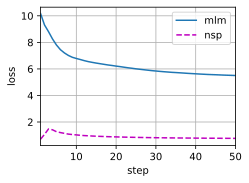

In [27]:
train_bert(train_iter, net, loss, len(vocab), devices, 50)

## Representing Text with BERT

In [28]:
def get_bert_encoding(net, tokens_a, tokens_b=None):
    tokens, segments = d2l.get_tokens_and_segments(tokens_a, tokens_b)
    token_ids = torch.tensor(vocab[tokens], device=devices[0]).unsqueeze(0)
    segments = torch.tensor(segments, device=devices[0]).unsqueeze(0)
    valid_len = torch.tensor(len(tokens), device=devices[0]).unsqueeze(0)
    encoded_X, _, _ = net(token_ids, segments, valid_len)
    return encoded_X

### Example with N = 1

In [29]:
tokens_a = ['a', 'crane', 'is', 'flying']
encoded_text = get_bert_encoding(net, tokens_a)
# Tokens: '<cls>', 'a', 'crane', 'is', 'flying', '<sep>'
encoded_text_cls = encoded_text[:, 0, :]
encoded_text_crane = encoded_text[:, 2, :]
encoded_text.shape, encoded_text_cls.shape, encoded_text_crane[0][:3]

(torch.Size([1, 6, 128]),
 torch.Size([1, 128]),
 tensor([ 0.2260,  1.9907, -0.2499], grad_fn=<SliceBackward0>))

In [30]:
tokens_a, tokens_b = ['a', 'crane', 'driver', 'came'], ['he', 'just', 'left']
encoded_pair = get_bert_encoding(net, tokens_a, tokens_b)
# Tokens: '<cls>', 'a', 'crane', 'driver', 'came', '<sep>', 'he', 'just',
# 'left', '<sep>'
encoded_pair_cls = encoded_pair[:, 0, :]
encoded_pair_crane = encoded_pair[:, 2, :]
encoded_pair.shape, encoded_pair_cls.shape, encoded_pair_crane[0][:3]

(torch.Size([1, 10, 128]),
 torch.Size([1, 128]),
 tensor([-0.0195,  0.9664, -0.8064], grad_fn=<SliceBackward0>))

### Example with N > 1

In [31]:
def get_bert_encoding_batch(net, sentences, vocab, devices, max_len=64):
    """
    Get BERT encodings for N sentences.
    
    Parameters
    ----------
    sentences : list of list of str
        N sentences, each a list of tokens e.g. [['a', 'crane', 'is', 'flying'], ...]
    vocab : d2l.Vocab
        Vocabulary used during pretraining
    max_len : int
        Max sequence length — pad/truncate to this length
    
    Returns
    -------
    encoded : torch.Tensor
        Shape (N, max_len, num_hiddens)
    """
    all_token_ids = []
    all_segments  = []
    all_valid_lens = []

    for tokens_a in sentences:
        # Build tokens + segment IDs for single input
        tokens, segments = d2l.get_tokens_and_segments(tokens_a)

        # Convert tokens to vocab indices
        token_ids = vocab[tokens]

        # Track valid length before padding
        valid_len = len(token_ids)

        # Pad or truncate to max_len
        token_ids = token_ids + [vocab['<pad>']] * (max_len - len(token_ids))
        segments  = segments  + [0]             * (max_len - len(segments))

        all_token_ids.append(token_ids[:max_len])
        all_segments.append(segments[:max_len])
        all_valid_lens.append(valid_len)

    # Stack into tensors of shape (N, max_len)
    token_ids_tensor  = torch.tensor(all_token_ids,  device=devices[0])
    segments_tensor   = torch.tensor(all_segments,   device=devices[0])
    valid_lens_tensor = torch.tensor(all_valid_lens, device=devices[0])

    # Single forward pass for all N sentences
    encoded, _, _ = net(token_ids_tensor, segments_tensor, valid_lens_tensor)
    return encoded

In [32]:
# --- Example: N = 3 sentences ---
sentences = [
    ['a', 'crane', 'is', 'flying'],
    ['a', 'crane', 'driver', 'came'],
    ['the', 'bank', 'approved', 'the', 'loan']
]

encoded_batch = get_bert_encoding_batch(net, sentences, vocab, devices)
print(encoded_batch.shape)  # (3, 64, 128)

# Extract [CLS] token representation for each sentence (index 0)
cls_representations = encoded_batch[:, 0, :]
print(cls_representations.shape)  # (3, 128)

torch.Size([3, 64, 128])
torch.Size([3, 128])


In [33]:
# 1. Get predictions from BERT for N sentences
encoded_batch = get_bert_encoding_batch(net, sentences, vocab, devices)

# 2. Get NSP logits from the [CLS] token via the hidden + nsp layers
cls_tokens = encoded_batch[:, 0, :]        # shape: (N, 128)
nsp_logits = net.nsp(net.hidden(cls_tokens))  # shape: (N, 2)
y_pred = nsp_logits.argmax(dim=1).cpu().numpy()

# 3. Your ground truth labels
y_true = [0, 1, 1]  # 0 = not next sentence, 1 = is next sentence
assert len(y_true) == len(y_pred)  # must be True

# 4. Use your EvaluationMetric class
report = EvaluationMetric.eval_classification_report(y_true, y_pred)
cm, tn, fp, fn, tp = EvaluationMetric.get_confusion_matrix(y_true, y_pred, by_category=True)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.67      1.00      0.80         2

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3



/Users/detraviousjamaribrinkley/Documents/Development/research_labs/uf_ds/predictions/.venv_predictions/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/detraviousjamaribrinkley/Documents/Development/research_labs/uf_ds/predictions/.venv_predictions/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/detraviousjamaribrinkley/Documents/Development/research_labs/uf_ds/predictions/.venv_predictions/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833

# References

1. BOOK: [Dive into Deep Learning](https://d2l.ai/chapter_natural-language-processing-pretraining/bert.html)
2. CLASS: CSCI-544: Applied Natural Language Processing (NLP) at USC by [Xuezhe Ma (Max)](https://xuezhemax.github.io/)